In [73]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.8,
})

output_dir = Path('./paper_figures')
output_dir.mkdir(exist_ok=True)
print(f'Figures will be saved to: {output_dir.absolute()}')

Figures will be saved to: /Users/ihounie/repos/everysample-plots/paper_figures


In [ ]:
wandb_project = 'when2call'
wandb_entity = '<WB ENTITY>'

api = wandb.Api()
runs = api.runs(f'{wandb_entity}/{wandb_project}' if wandb_entity else wandb_project)
runs = [r for r in runs if 'f1' in r.tags or 'baseline' in r.tags]
print(f'Total runs found: {len(runs)}')


def _effective_loss_type(run):
    cfg = run.config or {} if run is not None else {}
    cfg_exp = cfg.get('exp', {})
    return cfg_exp.get('loss_type')


def _when2call_method_label(loss_type):
    loss_type_str = str(loss_type or '').strip().lower()
    method_map = {
        'avg_both': 'Avg',
        'aug_dual_both': 'Point',
        'penalty_both': 'Penalty',
        'dpo': 'DPO',
        'simpo': 'SimPO',
        'cpo': 'CPO',
        'cal_dpo': 'Cal-DPO',
    }
    return method_map.get(loss_type_str, (loss_type or 'unknown').replace('_', ' ').title())

Total runs found: 29


Saved figure to paper_figures/when2call_metrics_barplots.pdf


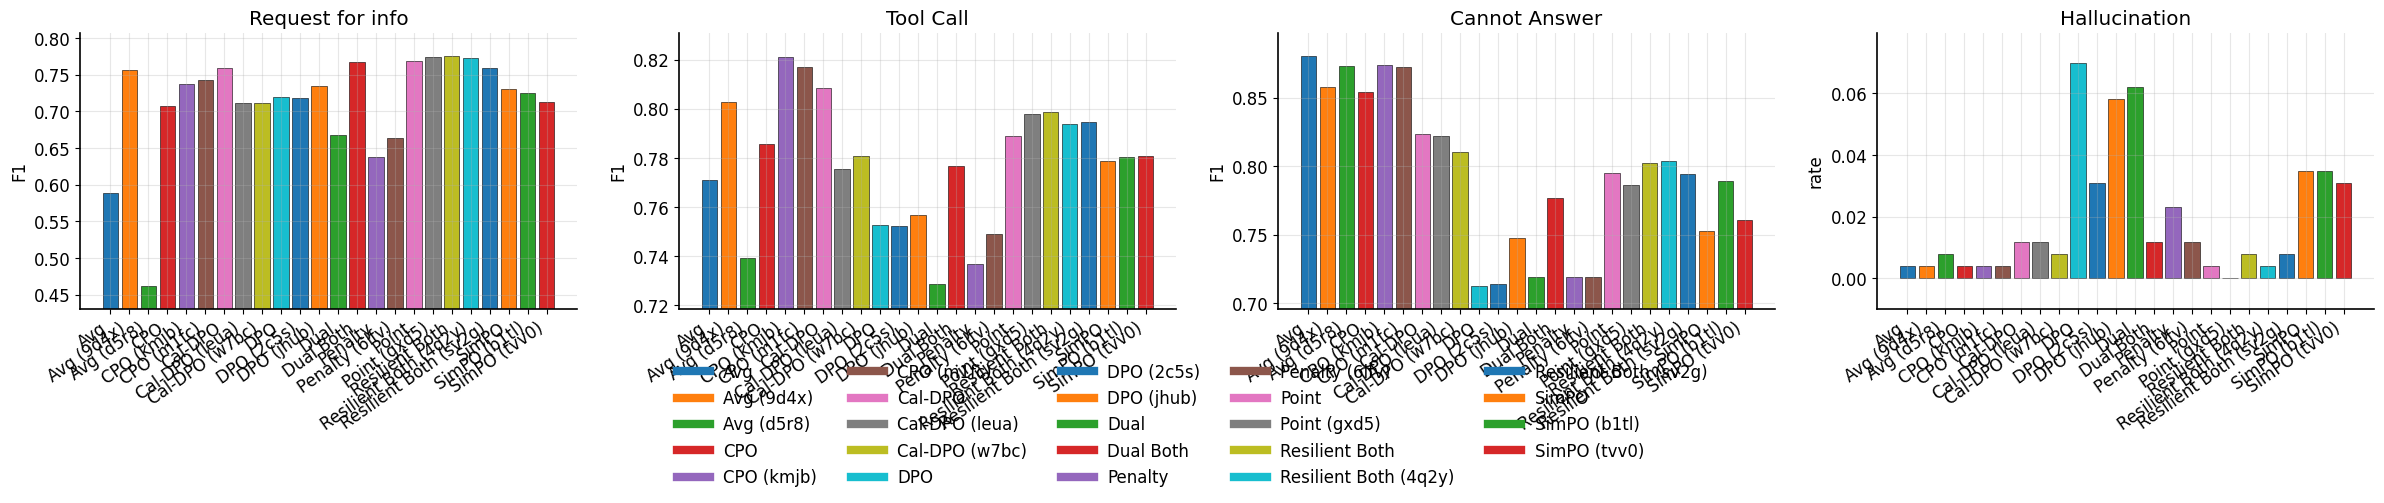

In [75]:
WHEN2CALL_PLOT_METRICS = {
    'when2call_lm_eval_vllm/per_category/request_for_info/f1': 'Request for info',
    'when2call_lm_eval_vllm/per_category/tool_call/f1': 'Tool Call',
    'when2call_lm_eval_vllm/per_category/cannot_answer/f1': 'Cannot Answer',
    'when2call_lm_eval_vllm/hallucination_rate': 'Hallucination',
}

WHEN2CALL_TABLE_METRICS = {
    **WHEN2CALL_PLOT_METRICS,
    'when2call_lm_eval_vllm/acc_norm,none': 'Accuracy',
}

rows = []
method_counts = {}
for run in runs:
    summary = run.summary or {}
    run_tags = {str(tag).lower() for tag in (run.tags or [])}
    is_baseline = 'baseline' in run_tags
    method_label = 'baseline' if is_baseline else _when2call_method_label(_effective_loss_type(run))

    method_counts[method_label] = method_counts.get(method_label, 0) + 1
    run_label = method_label
    if method_counts[method_label] > 1:
        run_label = f"{method_label} ({run.id[:4]})"

    row = {
        'RunId': run.id,
        'RunLabel': run_label,
        'MethodLabel': method_label,
        'IsBaseline': is_baseline,
    }

    has_any_metric = False
    for metric_key in WHEN2CALL_TABLE_METRICS:
        metric_val = summary.get(metric_key)
        try:
            metric_val = float(metric_val)
        except Exception:
            metric_val = np.nan
        if not np.isnan(metric_val):
            has_any_metric = True
        row[metric_key] = metric_val

    if has_any_metric:
        rows.append(row)

metrics_df_with_baseline = pd.DataFrame(rows)
if metrics_df_with_baseline.empty:
    print('No when2call metric values found in run summaries.')
    metrics_df = metrics_df_with_baseline.copy()
else:
    metrics_df_with_baseline = metrics_df_with_baseline.sort_values(['MethodLabel', 'RunLabel']).reset_index(drop=True)

    # Keep baseline rows for markdown table, but exclude them from barplots.
    metrics_df = metrics_df_with_baseline[~metrics_df_with_baseline['IsBaseline']].copy()

    if metrics_df.empty:
        print('No non-baseline runs available for barplots.')
    else:
        metric_items = list(WHEN2CALL_PLOT_METRICS.items())
        fig, axes = plt.subplots(1, len(metric_items), figsize=(6 * len(metric_items), 5), sharey=False)

        if len(metric_items) == 1:
            axes = [axes]

        palette = plt.rcParams.get('axes.prop_cycle', None)
        colors = (palette.by_key().get('color') if palette is not None else None) or [
            'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple',
            'tab:brown', 'tab:pink', 'tab:gray'
        ]
        run_ids = metrics_df['RunId'].tolist()
        color_by_run = {run_id: colors[i % len(colors)] for i, run_id in enumerate(run_ids)}

        for ax, (metric_key, metric_title) in zip(axes, metric_items):
            subset = metrics_df[['RunId', 'RunLabel', metric_key]].dropna().copy()

            ax.set_title(metric_title)
            y_label = 'rate' if metric_key == 'when2call_lm_eval_vllm/hallucination_rate' else 'F1'
            ax.set_ylabel(y_label)

            if subset.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
                ax.set_xticks([])
                continue

            x = np.arange(len(subset))
            y_vals = subset[metric_key].values
            bar_colors = [color_by_run[rid] for rid in subset['RunId']]
            ax.bar(x, y_vals, color=bar_colors, edgecolor='black', linewidth=0.4)
            ax.set_xticks(x)
            ax.set_xticklabels(subset['RunLabel'].tolist(), rotation=35, ha='right')

            y_min = float(np.min(y_vals))
            y_max = float(np.max(y_vals))
            if y_max <= y_min:
                pad = 0.05 if y_max == 0 else max(0.01, abs(y_max) * 0.1)
                ax.set_ylim(y_min - pad, y_max + pad)
            else:
                pad = max(0.01, 0.1 * (y_max - y_min))
                ax.set_ylim(y_min - pad, y_max + pad)

        legend_handles = [
            plt.Line2D([0], [0], color=color_by_run[rid], lw=6)
            for rid in run_ids
        ]
        legend_labels = metrics_df['RunLabel'].tolist()

        fig.legend(
            legend_handles,
            legend_labels,
            loc='lower center',
            ncol=min(5, max(1, len(legend_labels))),
            frameon=False,
            bbox_to_anchor=(0.5, -0.02),
        )
        fig.tight_layout(rect=[0, 0.08, 1, 1])

        metric_plot_path = output_dir / 'when2call_metrics_barplots.pdf'
        plt.savefig(metric_plot_path)
        print(f'Saved figure to {metric_plot_path}')
        plt.show()

Saved figure to paper_figures/when2call_metrics_grouped_with_hallucination_and_accuracy.pdf


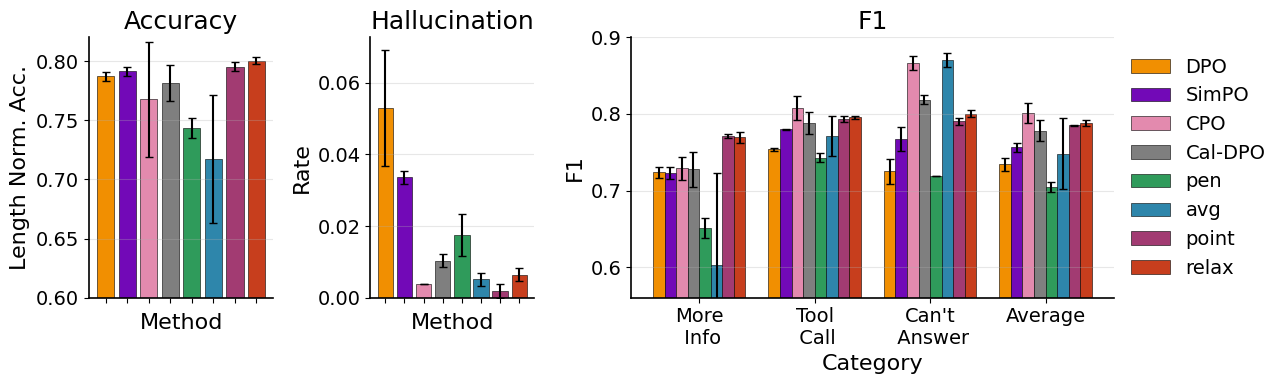

In [76]:
# Grouped barplots by metric, with hallucination and accuracy side panels.
metric_subset = [
    ('when2call_lm_eval_vllm/per_category/request_for_info/f1', 'More\n Info'),
    ('when2call_lm_eval_vllm/per_category/tool_call/f1', 'Tool\n Call'),
    ('when2call_lm_eval_vllm/per_category/cannot_answer/f1', "Can't\n Answer"),
]

if 'metrics_df' not in globals() or metrics_df.empty:
    print('metrics_df is empty. Run the previous cell first.')
elif 'runs' not in globals():
    print('runs are not available. Run the wandb cell first.')
else:
    def _canonical_method_name(name):
        method = str(name).strip()
        key = method.lower()
        canonical = {
            'penalty': 'Penalty',
            'pen': 'Penalty',
            'avg': 'Avg',
            'point': 'Point',
            'resilient both': 'Resilient Both',
            'resilient': 'Resilient Both',
            'res': 'Resilient Both',
            'cpo': 'CPO',
            'cal dpo': 'Cal-DPO',
            'cal_dpo': 'Cal-DPO',
        }
        return canonical.get(key, method)

    def _extract_train_seed(run):
        cfg = run.config or {}
        if not isinstance(cfg, dict):
            return None
        if isinstance(cfg.get('train'), dict) and 'seed' in cfg['train']:
            return cfg['train']['seed']
        for key in ('train.seed', 'train_seed', 'seed'):
            if key in cfg:
                return cfg[key]
        return None

    run_meta = []
    for run in runs:
        run_meta.append({
            'RunId': run.id,
            'LossType': _effective_loss_type(run) if '_effective_loss_type' in globals() else None,
            'TrainSeed': _extract_train_seed(run),
        })

    run_meta_df = pd.DataFrame(run_meta)
    plot_metrics_df = metrics_df.merge(run_meta_df, on='RunId', how='left')
    plot_metrics_df['TrainSeed'] = pd.to_numeric(plot_metrics_df['TrainSeed'], errors='coerce')
    plot_metrics_df['Method'] = plot_metrics_df['MethodLabel'].map(_canonical_method_name)

    loss_type_str = plot_metrics_df['LossType'].fillna('').astype(str).str.lower()
    method_str = plot_metrics_df['Method'].fillna('').astype(str).str.lower()
    exclude_dual_runs = (
        loss_type_str.isin(['dual_both', 'dual'])
        | method_str.isin(['dual_both', 'dual'])
    )
    plot_metrics_df = plot_metrics_df[~exclude_dual_runs].copy()

    missing_seeds = plot_metrics_df['TrainSeed'].isna()
    if missing_seeds.any():
        missing_ids = plot_metrics_df.loc[missing_seeds, 'RunId'].unique()
        print(f'Warning: excluding {len(missing_ids)} runs without train.seed.')
        plot_metrics_df = plot_metrics_df.loc[~missing_seeds].copy()

    if plot_metrics_df.empty:
        print('No values available after filtering/excluding seeds.')
    else:
        seed_counts = plot_metrics_df.groupby('Method')['TrainSeed'].nunique().sort_values()
        missing_seed_counts = seed_counts[seed_counts < 3]
        if not missing_seed_counts.empty:
            print('Warning: expected 3 seeds per method; found:', missing_seed_counts.to_dict())

        long_rows = []
        for metric_key, metric_name in metric_subset:
            subset = plot_metrics_df[['Method', 'TrainSeed', metric_key]].dropna()
            for _, row in subset.iterrows():
                long_rows.append({
                    'Method': row['Method'],
                    'TrainSeed': row['TrainSeed'],
                    'Metric': metric_name,
                    'Value': float(row[metric_key]),
                })

        grouped_df = pd.DataFrame(long_rows)
        if grouped_df.empty:
            print('No values available for Request / Tool Call / Cannot Answer.')
        else:
            # Aggregate within each seed, then compute mean/std across seeds.
            seed_means = (
                grouped_df.groupby(['Metric', 'Method', 'TrainSeed'], as_index=False)['Value']
                .mean()
            )

            base_metric_order = [name for _, name in metric_subset]
            avg_seed_df = (
                seed_means[seed_means['Metric'].isin(base_metric_order)]
                .groupby(['Method', 'TrainSeed'], as_index=False)['Value']
                .mean()
                .assign(Metric='Average')
            )
            seed_means = pd.concat([seed_means, avg_seed_df], ignore_index=True)

            stats_df = (
                seed_means.groupby(['Metric', 'Method'], as_index=False)['Value']
                .agg(Mean='mean', Std=lambda s: float(np.std(s, ddof=0)))
            )

            metric_order = base_metric_order + ['Average']
            preferred_method_order = ['DPO', 'SimPO', 'CPO', 'Cal-DPO', 'Penalty', 'Avg', 'Point', 'Resilient Both']
            available_methods = list(stats_df['Method'].unique())
            methods = [m for m in preferred_method_order if m in available_methods]
            methods.extend(sorted([m for m in available_methods if m not in methods]))

            legend_label_by_method = {
                'Penalty': 'pen',
                'Avg': 'avg',
                'Point': 'point',
                'Resilient Both': 'relax',
            }

            palette = plt.rcParams.get('axes.prop_cycle', None)
            colors = (palette.by_key().get('color') if palette is not None else None) or [
                'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple',
                'tab:brown', 'tab:pink', 'tab:gray'
            ]
            # Match method colors used in plotting_reranker.ipynb for these methods.
            reranker_method_colors = {
                'DPO': '#F18F01',
                'SimPO': '#7209B7',
                'CPO': '#E38AAE',
                'Cal-DPO': '#7F7F7F',
                'Avg': '#2E86AB',
                'Penalty': '#2F9B5B',
                'Point': '#A23B72',
                'Resilient Both': '#C73E1D',
            }
            color_by_method = {
                m: reranker_method_colors.get(m, colors[i % len(colors)])
                for i, m in enumerate(methods)
            }

            x = np.arange(len(metric_order))
            width = 0.8 / max(1, len(methods))

            hallucination_key = 'when2call_lm_eval_vllm/hallucination_rate'
            acc_key = 'when2call_lm_eval_vllm/acc_norm,none'

            fig, (ax_acc, ax_hall, ax_main) = plt.subplots(
                1,
                3,
                figsize=(13, 4),
                gridspec_kw={'width_ratios': [1.8, 1.6, 4.7]},
            )

            for i, method in enumerate(methods):
                method_vals = []
                method_errs = []
                for metric_name in metric_order:
                    row = stats_df[
                        (stats_df['Metric'] == metric_name)
                        & (stats_df['Method'] == method)
                    ]
                    if row.empty:
                        method_vals.append(np.nan)
                        method_errs.append(0.0)
                    else:
                        method_vals.append(float(row['Mean'].values[0]))
                        method_errs.append(float(row['Std'].values[0]))

                offset = (i - (len(methods) - 1) / 2.0) * width
                ax_main.bar(
                    x + offset,
                    method_vals,
                    width=width,
                    color=color_by_method[method],
                    edgecolor='black',
                    linewidth=0.4,
                    label=legend_label_by_method.get(method, method),
                    yerr=method_errs,
                    capsize=3,
                )

            title_fs = 18
            label_fs = 16
            tick_fs = 14
            legend_fs = 14

            ax_main.set_xticks(x)
            ax_main.set_xticklabels(metric_order, fontsize=tick_fs)
            ax_main.set_xlabel('Category', fontsize=label_fs)
            ax_main.set_ylabel('F1', fontsize=label_fs)
            ax_main.tick_params(axis='y', labelsize=tick_fs)
            ax_main.set_ylim(0.56, 0.90)
            ax_main.set_title('F1', fontsize=title_fs)
            ax_main.legend(
                frameon=False,
                ncol=1,
                loc='center left',
                bbox_to_anchor=(1.02, 0.5),
                borderaxespad=0.0,
                fontsize=legend_fs,
            )

            def _metric_seed_stats(df, metric_key, value_name):
                subset = df[['Method', 'TrainSeed', metric_key]].dropna()
                seed_vals = (
                    subset.groupby(['Method', 'TrainSeed'], as_index=False)[metric_key]
                    .mean()
                    .rename(columns={metric_key: value_name})
                )
                stats = (
                    seed_vals.groupby('Method', as_index=False)[value_name]
                    .agg(Mean='mean', Std=lambda s: float(np.std(s, ddof=0)))
                )
                return stats

            hall_stats = _metric_seed_stats(plot_metrics_df, hallucination_key, 'HallucinationRate')
            acc_stats = _metric_seed_stats(plot_metrics_df, acc_key, 'AccNorm')

            hall_subset = hall_stats[hall_stats['Method'].isin(methods)].copy()
            hall_subset['MethodOrder'] = hall_subset['Method'].apply(lambda m: methods.index(m))
            hall_subset = hall_subset.sort_values('MethodOrder')

            x_hall = np.arange(len(hall_subset))
            hall_colors = [color_by_method[m] for m in hall_subset['Method']]
            ax_hall.bar(
                x_hall,
                hall_subset['Mean'].values,
                yerr=hall_subset['Std'].values,
                capsize=3,
                color=hall_colors,
                edgecolor='black',
                linewidth=0.4,
            )
            ax_hall.set_xticks(x_hall)
            ax_hall.set_xticklabels([])
            ax_hall.set_xlabel('Method', fontsize=label_fs)
            ax_hall.set_ylabel('Rate', fontsize=label_fs)
            ax_hall.tick_params(axis='y', labelsize=tick_fs)
            ax_hall.set_title('Hallucination', fontsize=title_fs)

            acc_subset = acc_stats[acc_stats['Method'].isin(methods)].copy()
            acc_subset['MethodOrder'] = acc_subset['Method'].apply(lambda m: methods.index(m))
            acc_subset = acc_subset.sort_values('MethodOrder')

            x_acc = np.arange(len(acc_subset))
            acc_colors = [color_by_method[m] for m in acc_subset['Method']]
            ax_acc.bar(
                x_acc,
                acc_subset['Mean'].values,
                yerr=acc_subset['Std'].values,
                capsize=3,
                color=acc_colors,
                edgecolor='black',
                linewidth=0.4,
            )
            ax_acc.set_xticks(x_acc)
            ax_acc.set_xticklabels([])
            ax_acc.set_xlabel('Method', fontsize=label_fs)
            ax_acc.set_ylabel('Length Norm. Acc.', fontsize=label_fs)
            ax_acc.tick_params(axis='y', labelsize=tick_fs)
            ax_acc.set_ylim(0.60, 0.82)
            ax_acc.set_title('Accuracy', fontsize=title_fs)

            for ax in (ax_acc, ax_hall, ax_main):
                ax.grid(axis='x', visible=False)

            fig.tight_layout()

            out_path = output_dir / 'when2call_metrics_grouped_with_hallucination_and_accuracy.pdf'
            plt.savefig(out_path, bbox_inches='tight', pad_inches=0.02)
            print(f'Saved figure to {out_path}')
            plt.show()

In [77]:
from IPython.display import HTML, display
import html

if 'metrics_df_with_baseline' not in globals() or metrics_df_with_baseline.empty:
    print('metrics_df_with_baseline is empty. Run the metrics collection cell first.')
else:
    metric_map = {
        'when2call_lm_eval_vllm/per_category/request_for_info/f1': 'Follow-up question F1',
        'when2call_lm_eval_vllm/per_category/tool_call/f1': 'Tool call F1',
        'when2call_lm_eval_vllm/per_category/cannot_answer/f1': 'Unable to answer F1',
        'when2call_lm_eval_vllm/acc_norm,none': 'Length Norm Acc',
        'when2call_lm_eval_vllm/hallucination_rate': 'Hallucination',
    }

    def _build_model_df_from_metrics_df(df, model_name):
        base = df[['MethodLabel', *metric_map.keys()]].copy()
        base = base.rename(columns={'MethodLabel': 'Method', **metric_map})
        base['Method'] = base['Method'].replace({'baseline': 'Baseline'})
        base['Model'] = model_name
        return base[['Model', 'Method', *metric_map.values()]]

    def _fallback_method_label(run):
        cfg = run.config or {}
        exp = cfg.get('exp', {}) if isinstance(cfg, dict) else {}
        loss_type = exp.get('loss_type') if isinstance(exp, dict) else None
        return str(loss_type) if loss_type is not None else 'unknown'

    def _build_model_df_from_wandb_runs(project_name, model_name):
        try:
            import wandb
            entity = globals().get('wandb_entity', None)
            project_path = f'{entity}/{project_name}' if entity else project_name
            api = wandb.Api()
            project_runs = api.runs(project_path)

            rows = []
            for run in project_runs:
                tags = {str(tag).lower() for tag in (run.tags or [])}
                if not ('f1' in tags or 'baseline' in tags):
                    continue

                summary = run.summary or {}
                if 'baseline' in tags:
                    method = 'Baseline'
                else:
                    if '_effective_loss_type' in globals() and '_when2call_method_label' in globals():
                        try:
                            method = _when2call_method_label(_effective_loss_type(run))
                        except Exception:
                            method = _fallback_method_label(run)
                    else:
                        method = _fallback_method_label(run)
                    if str(method).lower() == 'baseline':
                        method = 'Baseline'

                row = {'Model': model_name, 'Method': method}
                has_any_metric = False
                for raw_key, display_key in metric_map.items():
                    val = summary.get(raw_key)
                    try:
                        val = float(val)
                    except Exception:
                        val = np.nan
                    row[display_key] = val
                    if pd.notna(val):
                        has_any_metric = True

                if has_any_metric:
                    rows.append(row)

            if not rows:
                return pd.DataFrame(columns=['Model', 'Method', *metric_map.values()])

            out_df = pd.DataFrame(rows)
            out_df['Method'] = out_df['Method'].replace({'baseline': 'Baseline'})
            return out_df[['Model', 'Method', *metric_map.values()]]
        except Exception as exc:
            print(f"Could not fetch runs from '{project_name}': {exc}")
            return pd.DataFrame(columns=['Model', 'Method', *metric_map.values()])

    def _add_macro_f1(df):
        out = df.copy()
        out['Macro F1'] = out[[
            'Tool call F1', 'Follow-up question F1', 'Unable to answer F1'
        ]].mean(axis=1)
        return out

    def _collapse_mean_std(df):
        if df.empty:
            cols = ['Model', 'Method']
            for name in list(metric_map.values()) + ['Macro F1']:
                cols.extend([f'{name}_mean', f'{name}_std'])
            return pd.DataFrame(columns=cols)
        metric_cols_list = list(metric_map.values()) + ['Macro F1']
        rows = []
        for (model, method), grp in df.groupby(['Model', 'Method']):
            row = {'Model': model, 'Method': method}
            for col in metric_cols_list:
                s = pd.to_numeric(grp[col], errors='coerce').dropna()
                row[f'{col}_mean'] = float(s.mean()) if len(s) else np.nan
                row[f'{col}_std'] = float(np.std(s, ddof=0)) if len(s) > 1 else np.nan
            rows.append(row)
        return pd.DataFrame(rows)

    llama_raw = _build_model_df_from_metrics_df(metrics_df_with_baseline, 'Llama-3.2-1B-Instruct')
    llama_df = _collapse_mean_std(_add_macro_f1(llama_raw))

    # Pull runs from xlam_when2call with f1/baseline tags.
    xlam_raw = _build_model_df_from_wandb_runs('xlam_when2call', 'xLAM-2-1b-fc-r')

    def _normalize_xlam_method(method_name):
        key = ' '.join(str(method_name).strip().lower().replace('_', ' ').split())
        if key in {'both avg', 'avg both', 'avg'}:
            return 'avg'
        if key == 'baseline':
            return 'Baseline'
        if key == 'point':
            return 'Point'
        if key == 'dpo':
            return 'DPO'
        if key == 'simpo':
            return 'SimPO'
        if key == 'penalty':
            return 'Penalty'
        return str(method_name).strip()

    if not xlam_raw.empty:
        xlam_raw['Method'] = xlam_raw['Method'].apply(_normalize_xlam_method)

    xlam_df = _collapse_mean_std(_add_macro_f1(xlam_raw))

    # Add requested hardcoded rows for Mistral-NeMo-Minitron.
    mistral_rows = pd.DataFrame([
        {
            'Model': 'Mistral-NeMo-Minitron',
            'Method': 'Baseline',
            'Tool call F1': 0.658,
            'Follow-up question F1': 0.333,
            'Unable to answer F1': 0.283,
            'Length Norm Acc': 0.491,
            'Hallucination': 0.190,
        },
        {
            'Model': 'Mistral-NeMo-Minitron',
            'Method': 'RPO',
            'Tool call F1': 0.748,
            'Follow-up question F1': 0.636,
            'Unable to answer F1': 0.711,
            'Length Norm Acc': 0.700,
            'Hallucination': 0.012,
        },
    ])

    mistral_df = _collapse_mean_std(_add_macro_f1(mistral_rows))

    combined_df = pd.concat([llama_df, xlam_df, mistral_df], ignore_index=True)

    stat_cols = list(metric_map.values()) + ['Macro F1']
    combined_df = combined_df[[
        'Model', 'Method',
        *[f'{c}_mean' for c in stat_cols],
        *[f'{c}_std' for c in stat_cols],
    ]]

    def _method_norm_for_filter(m):
        return ' '.join(str(m).strip().lower().replace('_', ' ').split())

    combined_df = combined_df[
        ~combined_df['Method'].map(_method_norm_for_filter).isin({'dual', 'dual both'})
    ].copy()

    combined_df['Method'] = combined_df['Method'].replace({
        'Baseline': 'Base',
        'Penalty': 'pen',
        'Point': 'point',
        'Resilient Both': 'res',
    })

    # Keep a stable display order.
    method_order = ['Base', 'DPO', 'SimPO', 'CPO', 'Cal-DPO', 'pen', 'avg', 'Avg', 'point', 'res', 'RPO']
    model_order = ['Mistral-NeMo-Minitron', 'Llama-3.2-1B-Instruct', 'xLAM-2-1b-fc-r']

    combined_df['__model_order'] = combined_df['Model'].apply(
        lambda m: model_order.index(m) if m in model_order else len(model_order)
    )
    combined_df['__method_order'] = combined_df['Method'].apply(
        lambda m: method_order.index(m) if m in method_order else len(method_order)
    )
    combined_df = combined_df.sort_values(
        ['__model_order', '__method_order', 'Method']
    ).drop(columns=['__model_order', '__method_order'])

    gray_html = '#888888'

    def fmt_pm(mean_val, std_val):
        if pd.isna(mean_val):
            return ''
        mean_str = f'{100.0 * float(mean_val):.1f}'
        if pd.isna(std_val):
            return mean_str
        std_str = f'{100.0 * float(std_val):.1f}'
        return f'{mean_str}<span style="color:{gray_html}"> ± {std_str}</span>'

    f1_cols = [
        'Tool call F1',
        'Follow-up question F1',
        'Unable to answer F1',
        'Macro F1',
    ]
    f1_header_labels = {
        'Tool call F1': 'Tool call (↑)',
        'Follow-up question F1': 'Follow-up question (↑)',
        'Unable to answer F1': 'Unable to answer (↑)',
        'Macro F1': 'Macro average (↑)',
    }
    other_cols = ['Length Norm Acc', 'Hallucination']
    other_header_labels = {
        'Length Norm Acc': 'Length Norm Acc (↑)',
        'Hallucination': 'Hallucination (↓)',
    }
    metric_cols = [*f1_cols, *other_cols]

    # Render HTML table with rowspan to merge model cells.
    rows_html = []
    for model_name, group in combined_df.groupby('Model', sort=False):
        group = group.reset_index(drop=True)
        rowspan = len(group)
        for i, r in group.iterrows():
            cells = []
            if i == 0:
                cells.append(f"<td rowspan='{rowspan}'>{html.escape(str(model_name))}</td>")
            cells.append(f"<td>{html.escape(str(r['Method']))}</td>")
            for c in metric_cols:
                cells.append(
                    f"<td>{fmt_pm(r[f'{c}_mean'], r[f'{c}_std'])}</td>"
                )
            rows_html.append('<tr>' + ''.join(cells) + '</tr>')

    table_html = (
        '<table>'
        '<thead>'
        '<tr>'
        "<th rowspan='2'>Model</th>"
        "<th rowspan='2'>Method</th>"
        + f"<th colspan='{len(f1_cols)}'>F1 (↑)</th>"
        + ''.join([f"<th rowspan='2'>{html.escape(other_header_labels[col])}</th>" for col in other_cols])
        + '</tr>'
        + '<tr>'
        + ''.join([f"<th>{html.escape(f1_header_labels[col])}</th>" for col in f1_cols])
        + '</tr>'
        + '</thead>'
        + '<tbody>'
        + ''.join(rows_html)
        + '</tbody></table>'
    )

    display(HTML(table_html))

In [78]:
from IPython.display import Markdown, display

if 'combined_df' not in globals() or combined_df.empty:
    print('combined_df is empty. Run the previous table cell first.')
else:
    f1_cols = [
        'Tool call F1',
        'Follow-up question F1',
        'Unable to answer F1',
        'Macro F1',
    ]
    other_cols = ['Length Norm Acc', 'Hallucination']
    stat_cols = [*f1_cols, *other_cols]
    ordered_cols = ['Model', 'Method'] + [
        x for c in stat_cols for x in (f'{c}_mean', f'{c}_std')
    ]

    latex_df = combined_df[ordered_cols].copy()

    _higher_is_better_cols = set(f1_cols + ['Length Norm Acc'])

    def _is_minitron_model(model_name):
        return 'minitron' in str(model_name).lower()

    def _emphasis_rank_by_column_per_model(df, stat_columns):
        """Map (Model, Method) -> 'best' | 'second' | None per metric column, within each model block.

        Rows belonging to Mistral-NeMo-Minitron are excluded from emphasis."""
        out = {c: {} for c in stat_columns}
        for col in stat_columns:
            higher = col in _higher_is_better_cols
            mean_col = f'{col}_mean'
            for _, g in df.groupby('Model', sort=False):
                model_name = g['Model'].iloc[0]
                if _is_minitron_model(model_name):
                    continue
                sub = g[['Model', 'Method', mean_col]].dropna(subset=[mean_col])
                if sub.empty:
                    continue
                vals = {
                    (r['Model'], r['Method']): float(r[mean_col])
                    for _, r in sub.iterrows()
                }
                uniq = sorted(set(vals.values()), reverse=higher)
                best_v = uniq[0]
                second_v = uniq[1] if len(uniq) > 1 else None
                for key, v in vals.items():
                    if v == best_v:
                        out[col][key] = 'best'
                    elif second_v is not None and v == second_v:
                        out[col][key] = 'second'
        return out

    _cell_emphasis = _emphasis_rank_by_column_per_model(latex_df, stat_cols)

    def fmt_latex_mean_pm(mean_val, std_val, emphasis=None):
        if pd.isna(mean_val):
            return '--'
        mean_str = f'{100.0 * float(mean_val):.1f}'
        gray = ''
        if not pd.isna(std_val):
            std_str = f'{100.0 * float(std_val):.1f}'
            gray = rf'\textcolor{{gray}}{{$\pm$\,{std_str}}}'

        if emphasis == 'best':
            mean_part = rf'\textbf{{{mean_str}}}'
        elif emphasis == 'second':
            mean_part = rf'\underline{{{mean_str}}}'
        else:
            mean_part = mean_str
        return mean_part + gray

    def esc(s):
        s = str(s)
        return (
            s.replace('\\', r'\\textbackslash{}')
             .replace('&', r'\\&')
             .replace('%', r'\\%')
             .replace('$', r'\\$')
             .replace('#', r'\\#')
             .replace('_', r'\\_')
             .replace('{', r'\\{')
             .replace('}', r'\\}')
             .replace('~', r'\\textasciitilde{}')
             .replace('^', r'\\textasciicircum{}')
        )

    groups = list(latex_df.groupby('Model', sort=False))

    lines = [
        r'% Requires: \usepackage{booktabs}, \usepackage{multirow}, and \usepackage{xcolor}',
        r'\begin{table}[t]',
        r'\centering',
        r'\small',
        r'\begin{tabular}{llcccccc}',
        r'\toprule',
        r'\multirow{2}{*}{Model} & \multirow{2}{*}{Method} & \multicolumn{4}{c}{F1 ($\uparrow$)} & \multirow{2}{*}{Length Norm Acc ($\uparrow$)} & \multirow{2}{*}{Hallucination ($\downarrow$)} \\',
        r'\cmidrule(lr){3-6}',
        r' & & Tool call ($\uparrow$) & Follow-up question ($\uparrow$) & Unable to answer ($\uparrow$) & Macro average ($\uparrow$) & & \\',
        r'\midrule',
    ]

    for gi, (model_name, group) in enumerate(groups):
        group = group.reset_index(drop=True)
        rowspan = len(group)

        for i, row in group.iterrows():
            model_cell = rf'\multirow{{{rowspan}}}{{*}}{{{esc(model_name)}}}' if i == 0 else ''
            row_key = (row['Model'], row['Method'])
            row_cells = [
                model_cell,
                esc(row['Method']),
                fmt_latex_mean_pm(
                    row['Tool call F1_mean'],
                    row['Tool call F1_std'],
                    _cell_emphasis['Tool call F1'].get(row_key),
                ),
                fmt_latex_mean_pm(
                    row['Follow-up question F1_mean'],
                    row['Follow-up question F1_std'],
                    _cell_emphasis['Follow-up question F1'].get(row_key),
                ),
                fmt_latex_mean_pm(
                    row['Unable to answer F1_mean'],
                    row['Unable to answer F1_std'],
                    _cell_emphasis['Unable to answer F1'].get(row_key),
                ),
                fmt_latex_mean_pm(
                    row['Macro F1_mean'],
                    row['Macro F1_std'],
                    _cell_emphasis['Macro F1'].get(row_key),
                ),
                fmt_latex_mean_pm(
                    row['Length Norm Acc_mean'],
                    row['Length Norm Acc_std'],
                    _cell_emphasis['Length Norm Acc'].get(row_key),
                ),
                fmt_latex_mean_pm(
                    row['Hallucination_mean'],
                    row['Hallucination_std'],
                    _cell_emphasis['Hallucination'].get(row_key),
                ),
            ]
            lines.append(' & '.join(row_cells) + r' \\')

        if gi < len(groups) - 1:
            lines.append(r'\midrule')

    lines.extend([
        r'\bottomrule',
        r'\end{tabular}',
        r'\caption{When2Call results across models and methods. Entries are mean $\pm$ standard deviation across runs at percent scale (without the \% symbol); the $\pm$ and deviation are gray when more than one run is available. Within each model block (except Mistral-NeMo-Minitron), each metric column marks the best mean in \textbf{bold} and the second-best in \underline{underline} (higher is better except hallucination ($\downarrow$)).}',
        r'\label{tab:when2call_results}',
        r'\end{table}',
    ])

    latex_table = '\n'.join(lines)
    display(Markdown(f'```latex\n{latex_table}\n```'))
    print(latex_table)

```latex
% Requires: \usepackage{booktabs}, \usepackage{multirow}, and \usepackage{xcolor}
\begin{table}[t]
\centering
\small
\begin{tabular}{llcccccc}
\toprule
\multirow{2}{*}{Model} & \multirow{2}{*}{Method} & \multicolumn{4}{c}{F1 ($\uparrow$)} & \multirow{2}{*}{Length Norm Acc ($\uparrow$)} & \multirow{2}{*}{Hallucination ($\downarrow$)} \\
\cmidrule(lr){3-6}
 & & Tool call ($\uparrow$) & Follow-up question ($\uparrow$) & Unable to answer ($\uparrow$) & Macro average ($\uparrow$) & & \\
\midrule
\multirow{2}{*}{Mistral-NeMo-Minitron} & Base & 65.8 & 33.3 & 28.3 & 42.5 & 49.1 & 19.0 \\
 & RPO & \underline{\textbf{74.8}} & \underline{\textbf{63.6}} & \underline{\textbf{71.1}} & \underline{\textbf{69.8}} & \underline{\textbf{70.0}} & \underline{\textbf{1.2}} \\
\midrule
\multirow{9}{*}{Llama-3.2-1B-Instruct} & Base & 57.3 & 8.3 & 8.5 & 24.7 & 47.6 & 52.3 \\
 & DPO & 75.4\textcolor{gray}{$\pm$\,0.2} & 72.4\textcolor{gray}{$\pm$\,0.7} & 72.5\textcolor{gray}{$\pm$\,1.6} & 73.4\textcolor{gray}{$\pm$\,0.8} & 78.7\textcolor{gray}{$\pm$\,0.4} & 5.3\textcolor{gray}{$\pm$\,1.6} \\
 & SimPO & 78.0\textcolor{gray}{$\pm$\,0.1} & 72.3\textcolor{gray}{$\pm$\,0.8} & 76.7\textcolor{gray}{$\pm$\,1.6} & 75.7\textcolor{gray}{$\pm$\,0.6} & 79.1\textcolor{gray}{$\pm$\,0.4} & 3.4\textcolor{gray}{$\pm$\,0.2} \\
 & CPO & \underline{\textbf{80.8}}\textcolor{gray}{$\pm$\,1.6} & 72.9\textcolor{gray}{$\pm$\,1.5} & 86.7\textcolor{gray}{$\pm$\,0.9} & \underline{\textbf{80.1}}\textcolor{gray}{$\pm$\,1.3} & 76.8\textcolor{gray}{$\pm$\,4.9} & 0.4\textcolor{gray}{$\pm$\,0.0} \\
 & Cal-DPO & 78.8\textcolor{gray}{$\pm$\,1.4} & 72.8\textcolor{gray}{$\pm$\,2.3} & 81.9\textcolor{gray}{$\pm$\,0.6} & 77.8\textcolor{gray}{$\pm$\,1.3} & 78.1\textcolor{gray}{$\pm$\,1.5} & 1.0\textcolor{gray}{$\pm$\,0.2} \\
 & pen & 74.3\textcolor{gray}{$\pm$\,0.6} & 65.1\textcolor{gray}{$\pm$\,1.3} & 71.9\textcolor{gray}{$\pm$\,0.0} & 70.4\textcolor{gray}{$\pm$\,0.7} & 74.4\textcolor{gray}{$\pm$\,0.8} & 1.7\textcolor{gray}{$\pm$\,0.6} \\
 & Avg & 77.1\textcolor{gray}{$\pm$\,2.6} & 60.2\textcolor{gray}{$\pm$\,12.1} & \underline{\textbf{87.1}}\textcolor{gray}{$\pm$\,1.0} & 74.8\textcolor{gray}{$\pm$\,4.7} & 71.7\textcolor{gray}{$\pm$\,5.4} & 0.5\textcolor{gray}{$\pm$\,0.2} \\
 & point & 79.3\textcolor{gray}{$\pm$\,0.4} & \underline{\textbf{77.2}}\textcolor{gray}{$\pm$\,0.3} & 79.1\textcolor{gray}{$\pm$\,0.4} & 78.5\textcolor{gray}{$\pm$\,0.1} & 79.5\textcolor{gray}{$\pm$\,0.4} & \underline{\textbf{0.2}}\textcolor{gray}{$\pm$\,0.2} \\
 & res & 79.6\textcolor{gray}{$\pm$\,0.2} & 76.9\textcolor{gray}{$\pm$\,0.7} & 80.0\textcolor{gray}{$\pm$\,0.4} & 78.8\textcolor{gray}{$\pm$\,0.4} & \underline{\textbf{80.0}}\textcolor{gray}{$\pm$\,0.3} & 0.6\textcolor{gray}{$\pm$\,0.2} \\
\midrule
\multirow{9}{*}{xLAM-2-1b-fc-r} & Base & 57.2 & 11.2 & 12.1 & 26.8 & 42.9 & 57.8 \\
 & DPO & 78.1\textcolor{gray}{$\pm$\,1.1} & 75.3\textcolor{gray}{$\pm$\,1.2} & 82.4\textcolor{gray}{$\pm$\,0.9} & 78.6\textcolor{gray}{$\pm$\,1.1} & 80.5\textcolor{gray}{$\pm$\,0.5} & 1.8\textcolor{gray}{$\pm$\,0.5} \\
 & SimPO & 74.0\textcolor{gray}{$\pm$\,2.0} & 72.1\textcolor{gray}{$\pm$\,0.3} & 81.4\textcolor{gray}{$\pm$\,0.3} & 75.9\textcolor{gray}{$\pm$\,0.8} & 78.2\textcolor{gray}{$\pm$\,1.6} & 0.3\textcolor{gray}{$\pm$\,0.2} \\
 & CPO & 82.0\textcolor{gray}{$\pm$\,5.6} & 70.5\textcolor{gray}{$\pm$\,9.4} & 83.4\textcolor{gray}{$\pm$\,5.3} & 78.7\textcolor{gray}{$\pm$\,6.8} & 80.3\textcolor{gray}{$\pm$\,4.6} & 4.5\textcolor{gray}{$\pm$\,6.4} \\
 & Cal-DPO & 80.8\textcolor{gray}{$\pm$\,0.5} & 76.6\textcolor{gray}{$\pm$\,0.2} & 84.9\textcolor{gray}{$\pm$\,0.3} & 80.8\textcolor{gray}{$\pm$\,0.1} & 81.2\textcolor{gray}{$\pm$\,0.3} & \underline{\textbf{0.0}}\textcolor{gray}{$\pm$\,0.0} \\
 & pen & 79.5\textcolor{gray}{$\pm$\,0.7} & 71.6\textcolor{gray}{$\pm$\,0.4} & 81.5\textcolor{gray}{$\pm$\,0.7} & 77.6\textcolor{gray}{$\pm$\,0.5} & 78.9\textcolor{gray}{$\pm$\,0.7} & 0.9\textcolor{gray}{$\pm$\,0.5} \\
 & avg & \underline{\textbf{84.1}}\textcolor{gray}{$\pm$\,0.9} & 75.8\textcolor{gray}{$\pm$\,0.5} & 86.2\textcolor{gray}{$\pm$\,0.6} & 82.0\textcolor{gray}{$\pm$\,0.5} & 82.1\textcolor{gray}{$\pm$\,0.6} & \underline{\textbf{0.0}}\textcolor{gray}{$\pm$\,0.0} \\
 & point & 83.6\textcolor{gray}{$\pm$\,0.3} & 80.9\textcolor{gray}{$\pm$\,0.4} & 86.1\textcolor{gray}{$\pm$\,0.4} & 83.5\textcolor{gray}{$\pm$\,0.2} & 83.7\textcolor{gray}{$\pm$\,0.2} & \underline{\textbf{0.0}}\textcolor{gray}{$\pm$\,0.0} \\
 & res & 84.0\textcolor{gray}{$\pm$\,0.3} & \underline{\textbf{81.1}}\textcolor{gray}{$\pm$\,0.4} & \underline{\textbf{86.4}}\textcolor{gray}{$\pm$\,0.3} & \underline{\textbf{83.8}}\textcolor{gray}{$\pm$\,0.3} & \underline{\textbf{84.1}}\textcolor{gray}{$\pm$\,0.1} & \underline{\textbf{0.0}}\textcolor{gray}{$\pm$\,0.0} \\
\bottomrule
\end{tabular}
\caption{When2Call results across models and methods. Entries are mean $\pm$ standard deviation across runs at percent scale (without the \% symbol); the $\pm$ and deviation are gray when more than one run is available. Within each model block and metric column, the best mean is \textbf{\underline{bold and underlined}} (higher is better except hallucination ($\downarrow$)).}
\label{tab:when2call_results}
\end{table}
```

% Requires: \usepackage{booktabs}, \usepackage{multirow}, and \usepackage{xcolor}
\begin{table}[t]
\centering
\small
\begin{tabular}{llcccccc}
\toprule
\multirow{2}{*}{Model} & \multirow{2}{*}{Method} & \multicolumn{4}{c}{F1 ($\uparrow$)} & \multirow{2}{*}{Length Norm Acc ($\uparrow$)} & \multirow{2}{*}{Hallucination ($\downarrow$)} \\
\cmidrule(lr){3-6}
 & & Tool call ($\uparrow$) & Follow-up question ($\uparrow$) & Unable to answer ($\uparrow$) & Macro average ($\uparrow$) & & \\
\midrule
\multirow{2}{*}{Mistral-NeMo-Minitron} & Base & 65.8 & 33.3 & 28.3 & 42.5 & 49.1 & 19.0 \\
 & RPO & \underline{\textbf{74.8}} & \underline{\textbf{63.6}} & \underline{\textbf{71.1}} & \underline{\textbf{69.8}} & \underline{\textbf{70.0}} & \underline{\textbf{1.2}} \\
\midrule
\multirow{9}{*}{Llama-3.2-1B-Instruct} & Base & 57.3 & 8.3 & 8.5 & 24.7 & 47.6 & 52.3 \\
 & DPO & 75.4\textcolor{gray}{$\pm$\,0.2} & 72.4\textcolor{gray}{$\pm$\,0.7} & 72.5\textcolor{gray}{$\pm$\,1.6} & 73.4\textcolor{gray}{$\p